In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Evento Escolhido, Pergunta de Pesquisa e Hipótese Inicial

### O Evento
Em 30 de agosto de 2024, a rede social X (antigo Twitter) foi bloqueada no Brasil por determinação judicial do Supremo Tribunal Federal. Diante da alta incerteza sobre o retorno da plataforma, o mercado "Will Brazil unban X before October?" (ID: 506198) foi aberto no Polymarket, concentrando as apostas sobre a reversão da decisão ainda no mês de setembro.

### Pergunta de Pesquisa
Como os desdobramentos jurídicos e as sanções financeiras impostas ao X e à Starlink durante o mês de setembro de 2024 impactaram a probabilidade implícita e o volume de apostas no Polymarket? 

Utilizaremos os eventos mapeados pela **agênciaBrasil**, podendo ser acessada [nesse link](https://agenciabrasil.ebc.com.br/justica/noticia/2024-10/liberacao-do-x-confira-cronologia-da-suspensao-da-rede-social), para analisarmos no mercado do polymarket.

### Hipótese Inicial
A hipótese central é que decisões judiciais específicas alteraram bruscamente a precificação do mercado. Acredito que datas cruciais mapeadas pela cronologia oficial (como o bloqueio de bens da Starlink em 02/09, a transferência de multas milionárias em 13/09 e, principalmente, a recusa de desbloqueio pelo STF em 27/09) causarão anomalias visíveis no volume de negociações e quedas na probabilidade de resolução positiva do mercado.

## Exploração Inicial
A seguir, detalharemos as consultas inicias utilizadas para obter informações gerais sobre o mercado

### Consulta Inicial

```sql
SELECT market_id, question, closed, active, volume, created_at, end_date, updated_at
FROM `even-continuity-441808-j0.polymarket_optimized.markets` 
WHERE market_id LIKE "506198";
```

A consulta acima permitiu visualizar as informações iniciais sobre o mercado, retornando apenas uma linha:

![consulta_inicial](images/consulta-inicial.png)

Assim, confirmamos que o mercado está fechado, iniciou em 30/8 (logo após a suspensão do X) e finalizou em 30/9 (final do mês de setembro).

### Obtendo dados da tabela `polymarket_mart.daily_market_stats`

Em seguida, precisamos analisar o valor dos tokens de "SIM" e "NÃO" para mapearmos a opinião pública sobre o desbanimento ou não do X no mês de setembro.

Inicialmente, tentei obter os dados diários na tabela `polymarket_mart.daily_market_stats`. A tabela possui as seguintes colunas:
- market_id
- trade_date
- daily_trade_count 
- daily_usd_volume
- avg_trade_price 
- min_trade_price
- max_trade_price.

Assim, realizei a seguinte consulta para obter o valor de cada token médio por dia:




```sql
SELECT 
    trade_date,
    avg_trade_price AS probabilidade_media,
    min_trade_price AS probabilidade_minima,
    max_trade_price AS probabilidade_maxima,
    daily_usd_volume AS volume_diario_usd
FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
WHERE market_id = '506198'
  AND trade_date BETWEEN '2024-08-30' AND '2024-09-30'
ORDER BY 
    trade_date ASC;
```

No próprio Google Cloud, podemos visualizar o resultado da query acima com um gráfico gerado automaticamente, relacionando a data com a média do preço, preço máximo e preço mínimo de vendas por dia:

![grafico-dados-agregados-dia-sem-coerencia](grafico-dados-agregados-dia-sem-coerencia.png)

Segue a descrição do significado de cada linha e eixo:
- Eixo X: Data das vendas agregadas.
- Linha Verde: Valor máximo de uma venda registrado no dia.
- Linha Azul: Valor médio das vendas naquele dia.
- Linha Rosa: Valor mínimo das vendas naquele dia.

No entanto, observei um comportamento anômalo: a curva da probabilidade média (avg_trade_price) não refletia os acontecimentos reais mapeados na cronologia. Mesmo no final de setembro, quando o mercado tinha certeza absoluta de que o X não voltaria no mês, as médias ficavam em torno de 0.50 e 0.60.

Ao investigar o esquema e os dados dessa tabela Mart, descobri uma limitação: No Polymarket, cada mercado a venda simultânea de dois ativos (tokens) distintos: um para o "SIM" e outro para o "NÃO". Pela arquitetura da plataforma, a soma do preço desses dois tokens em um dado momento é sempre igual a $1.00.

Entretanto, processo de Engenharia de Dados que gerou a tabela daily_market_stats realizou o agrupamento (GROUP BY) apenas pelo identificador da pergunta (market_id). Com isso, a tabela misturou as transações de compra do "SIM" e do "NÃO" no mesmo número. Assim, no dia 29 de setembro, por exemplo, um usuário que comprou o token "NÃO" a $0.99 e outro que comprou o "SIM" a $0.01 foram somados e divididos pela tabela agregada, gerando uma média de $0.50, a tabela comprimiu ambos os dados.

Para capturar o variação do preço dos tokens de SIM e NÃO, decidi abandonar a tabela agregada e extrair os dados diretamente da tabela `polymarket_optimized.trades`.

### Obtendo os dados de `polymarket_optimized.trades`.
Esta tabela armazena o histórico das negociações executadas na plataforma, o que nos permite isolar o comportamento de cada aposta.

Nesta etapa, utilizamos as seguintes colunas da tabela:

- `trade_timestamp`: A data e hora exata em que a transação ocorreu. Utilizei a função DATE() sobre ela para agrupar o histórico diário das negociações.

- `asset_id`: O identificador único do ativo negociado. Essa é a coluna que diferencia as apostas a favor ("SIM") das apostas contra ("NÃO") dentro do mesmo mercado.

- `price`: Preço do token no momento da transação (variando de $0.00 a $1.00). A média deste valor representa a probabilidade média do token ganhar a aposta registrada naquele dia.

- `usd_amount`: Volume financeiro da transação em dólares, utilizado para calcular o peso das negociações por dia.

Assim, desenvolvi uma nova consulta agrupando os dados de preço por data e agrupando pela coluna asset_id. Para garantir a otimização de custos e respeitar as boas práticas do BigQuery, apliquei filtros de partição (BETWEEN em datas) e clusterização (market_id):


```sql
SELECT 
    DATE(trade_timestamp) AS trade_date,
    asset_id
    AVG(price) AS probabilidade_media,
    SUM(usd_amount) AS volume_diario_usd
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE market_id = '506198'
  AND DATE(trade_timestamp) BETWEEN '2024-08-30' AND '2024-09-30'
GROUP BY 
    trade_date,
    asset_id
ORDER BY 
    trade_date ASC;
```

A consulta acima resulta em um dataset onde cada dia possui duas linhas distintas: uma refletindo o valor médio da aposta positiva (o X será desbanido) e a outra reflete o valor médio negativo (o X não será desbanido). Os dados estão disponíveis em [valor-tokens-no-mes.csv](dados/valor-tokens-no-mes.csv) Segue abaixo o exemplo de valor para o último dia de aposta:

```csv
trade_date,asset_id,probabilidade_media,volume_diario_usd
2024-09-30,23727754999315416796891874310600601879712415166752939478817430508567693124251,0.965993152,13003.80
2024-09-30,53105094533820947480450262432453826023438327544619523650479668879266011588986,0.034006848,4521.50
```

Sabemos que o desbanimento do X não ocorreu em setembro. Assim, podemos identificar que o token que encerrou o mês beirando o preço de $1.00 é o token do "NÃO" (asset_id = 23727754999315416796891874310600601879712415166752939478817430508567693124251). Consequentemente, o outro ID gerado representa o token do "SIM".

Abaixo, apresento o código em Python utilizado para visualizar o preço da aposta negativa e positiva no deorrer do mês, utilizando `matplotlib`.

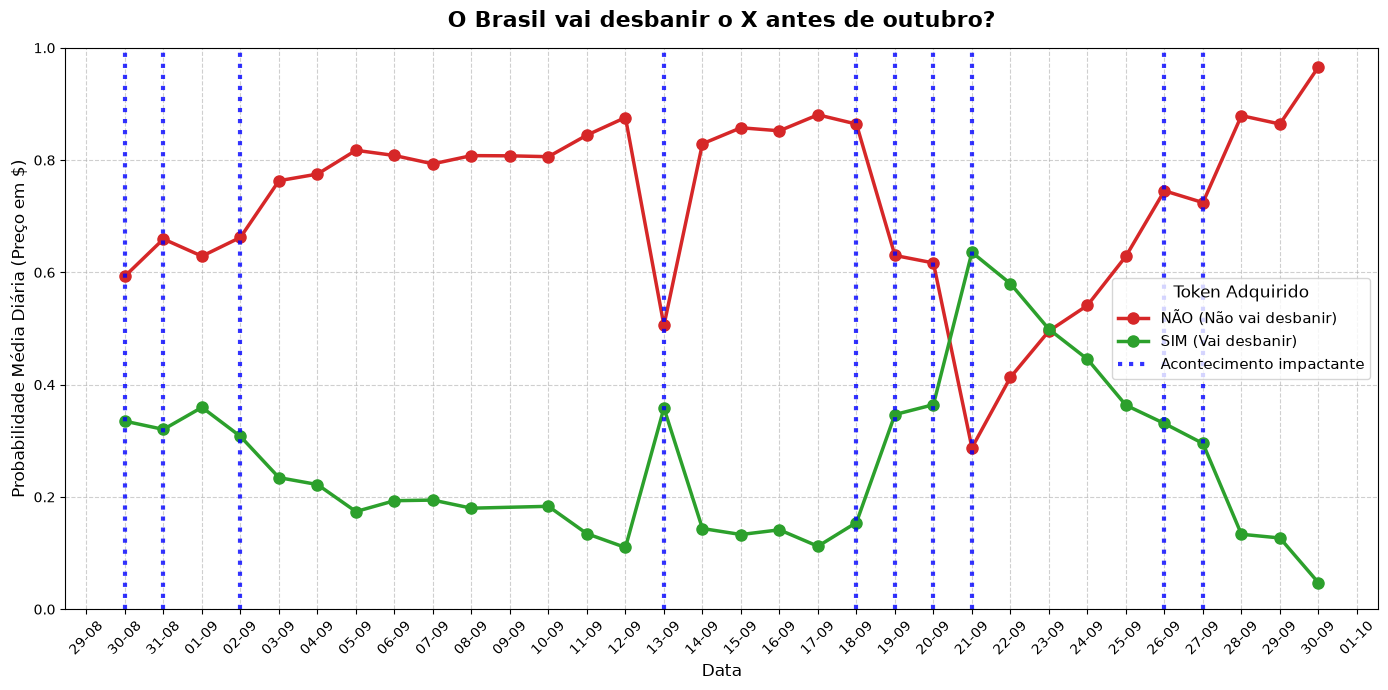

In [24]:
caminho_csv = 'dados/valor-tokens-no-mes.csv'

# 1. Carregando os dados exportados da query
df = pd.read_csv(caminho_csv)
df['trade_date'] = pd.to_datetime(df['trade_date'])

#mapeia o id da aposta negativa (não)
id_nao = '23727754999315416796891874310600601879712415166752939478817430508567693124251'

# classifica as linhas
df['Tipo_Aposta'] = df['asset_id'].apply(lambda x: 'NÃO (Não vai desbanir)' if str(x) == id_nao else 'SIM (Vai desbanir)')


plt.figure(figsize=(14, 7))
cores = {
    'SIM (Vai desbanir)': '#2ca02c', 
    'NÃO (Não vai desbanir)': '#d62728'
}

# itera sob cada aposta
for tipo, grupo in df.groupby('Tipo_Aposta'):
    plt.plot(
        grupo['trade_date'], 
        grupo['probabilidade_media'], 
        label=tipo, 
        color=cores.get(tipo, 'blue'), 
        marker='o', 
        linewidth=2.5, 
        markersize=8
    )

plt.title('O Brasil vai desbanir o X antes de outubro?', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Probabilidade Média Diária (Preço em $)', fontsize=12)

plt.ylim(0, 1)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1)) # força a marcação de 1 em 1 dia
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m')) # formato da data (dia e mes)
plt.xticks(rotation=45)

#melhorando os eixos, legenda e grades
plt.xticks(rotation=45)
plt.legend(title='Token Adquirido', fontsize=11, title_fontsize=12, loc='center left')
plt.grid(True, linestyle='--', alpha=0.6)

datas_eventos = [
    '2024-08-30', '2024-08-31', '2024-09-02', '2024-09-13', 
    '2024-09-18', '2024-09-19', '2024-09-20', '2024-09-21', 
    '2024-09-26', '2024-09-27'
]

# Adicionando as linhas verticais pontilhadas
legenda_inserida = False
for data_str in datas_eventos:
    # Converte para datetime para garantir alinhamento perfeito no eixo X do Pandas
    data_dt = pd.to_datetime(data_str)
    
    if not legenda_inserida:
        # Adiciona a label apenas na primeira linha para não poluir a legenda
        plt.axvline(x=data_dt, color='blue', linestyle=':', linewidth=3, alpha=0.8, label='Acontecimento impactante')
        legenda_inserida = True
    else:
        plt.axvline(x=data_dt, color='blue', linestyle=':', linewidth=3, alpha=0.8)

plt.legend(title='Token Adquirido', fontsize=11, title_fontsize=12, loc='center right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Note que, no gráfico acima, adicionamos a linha vertical azul para sinalizar eventos impactantes que ocorreram no dia, extraídos da nossa fonte **agênciaBrasil**, podendo ser acessada [nesse link](https://agenciabrasil.ebc.com.br/justica/noticia/2024-10/liberacao-do-x-confira-cronologia-da-suspensao-da-rede-social). Acesse o link para consultar a natureza do evento ocorrida em cada dia.

Note que nos dias **13/9**, **18/9**, **20/9**, **21/9** e **27/9** houve uma alta variação nas probabilidades das apostas. A variação coincindiu com eventos jurídicos que ocorreram nesses dias. Entretanto, não podemos afirmar com exatidão que a variação das probabilidades é totalmente atribuída a esses eventos, pois elas podem ser afetadas por fatores que não foram mapeados (pronunciamentos, tweets, etc).

Em seguida, desenvolveremos dois alertas que indicam movimentos atípicos das probabilidades acima.

## Desenvolvendo os Alertas
Para detectar momentos atípicos, utilizarei a variação entre as probabilidades dos dias. Nesse sentido, desenvolvi dois alertas. O **primeiro** olha para a diferença entre o preço de um dia e o seu anterior. O **segundo** olha para a variação percentual do montante financeiro negociado em relação ao dia anterior.
### Alerta 1 
Utilizamos a função SQL LAG() particionada por tipo de token (asset_id) para buscar o preço de fechamento do dia exatamente anterior. Em seguida, calculamos a diferença absoluta entre o preço de hoje e o de ontem. Se essa variação (Delta) for maior ou igual a 15% em um período de 24 horas, o alerta de "Alta Volatilidade de Probabilidade" é disparado.

### Alerta 2
Mede a variação percentual do montante financeiro negociado (SUM(usd_amount)) em relação ao dia anterior. O alerta de "ALERTA: Surto de Volume Financeiro (USD)" é acionado quando o volume diário dobra em relação ao dia anterior e apresenta um incremento absoluto de pelo menos $1.000 USD. Esses segundo filtro serve para impedir falsos positivos em dias de liquidez muito baixa.

## Query Completa dos Alertas

Abaixo, segue a query completa contendo os alertas.

```sql
WITH daily_aggregation AS (
    --mapeia o preço médio e a soma do usd_amount por dia
    SELECT 
        DATE(trade_timestamp) AS trade_date,
        asset_id,
        AVG(price) AS probabilidade_media,
        SUM(usd_amount) AS volume_diario_usd
    FROM `even-continuity-441808-j0.polymarket_optimized.trades`
    WHERE market_id = '506198'
      AND DATE(trade_timestamp) BETWEEN '2024-08-30' AND '2024-09-30'
    GROUP BY 
        trade_date, 
        asset_id
),

token_mapping AS (
    --mapeamento de Tokens (aposta positiva ou negativa)
    SELECT 
        trade_date,
        CASE 
            WHEN asset_id = '23727754999315416796891874310600601879712415166752939478817430508567693124251' 
            THEN 'NÃO (Não vai desbanir)'
            ELSE 'SIM (Vai desbanir)'
        END AS tipo_token,
        probabilidade_media,
        volume_diario_usd
    FROM daily_aggregation
),

lagged_metrics AS (
    --obtem o preço e volume (usd_amount) do dia anterior
    SELECT 
        trade_date,
        tipo_token,
        probabilidade_media,
        volume_diario_usd,
        --busca a probabilidade do dia exatamente anterior
        LAG(probabilidade_media) OVER(
            PARTITION BY tipo_token 
            ORDER BY trade_date ASC
        ) AS prob_dia_anterior,
        --busca o volume financeiro (usd_amount) do dia exatamente anterior
        LAG(volume_diario_usd) OVER(
            PARTITION BY tipo_token 
            ORDER BY trade_date ASC
        ) AS volume_dia_anterior
    FROM token_mapping
),

alert_logic AS (
    SELECT 
        trade_date,
        tipo_token,
        probabilidade_media,
        volume_diario_usd,
        
        -- variacoes absolutas e percentual
        ABS(probabilidade_media - prob_dia_anterior) AS variacao_probabilidade,
        (volume_diario_usd - volume_dia_anterior) AS variacao_volume_usd_abs,
        SAFE_DIVIDE(volume_diario_usd - volume_dia_anterior, volume_dia_anterior) AS variacao_volume_pct,
        
        -- alerta 1: choque de preço (> 15% de variação em 24h)
        CASE 
            WHEN ABS(probabilidade_media - prob_dia_anterior) >= 0.15 
            THEN 'ALERTA: Alta Volatilidade de Probabilidade'
            ELSE 'Normal'
        END AS alerta_preco,
        
        -- alerta 2: surto de volume financeiro (aumento > 100% no usd_amount negociado em 24h e delta mínimo relevante)
        CASE 
            WHEN SAFE_DIVIDE(volume_diario_usd - volume_dia_anterior, volume_dia_anterior) >= 1.00 
             AND (volume_diario_usd - volume_dia_anterior) >= 1000 
            THEN 'ALERTA: Surto de Volume Financeiro (USD)'
            ELSE 'Normal'
        END AS alerta_volume
    FROM lagged_metrics
)

-- consulta final
SELECT 
    trade_date,
    tipo_token,
    ROUND(probabilidade_media, 3) AS prob_atual,
    ROUND(variacao_probabilidade, 3) AS variacao_preco_24h,
    ROUND(volume_diario_usd, 2) AS volume_usd_atual,
    ROUND(variacao_volume_usd_abs, 2) AS delta_volume_usd,
    ROUND(variacao_volume_pct * 100, 1) AS crescimento_volume_pct,
    alerta_preco,
    alerta_volume
FROM alert_logic
WHERE alerta_preco LIKE 'ALERTA%' 
   OR alerta_volume LIKE 'ALERTA%'
ORDER BY 
    trade_date ASC, 
    tipo_token ASC;
``` 

Como resultado, é gerado um csv contendo os dados finais. Abaixo, utilizaremos pandas e matplotlib para gerar o gráfico final, contendo o momento em que os alertas foram disparados.


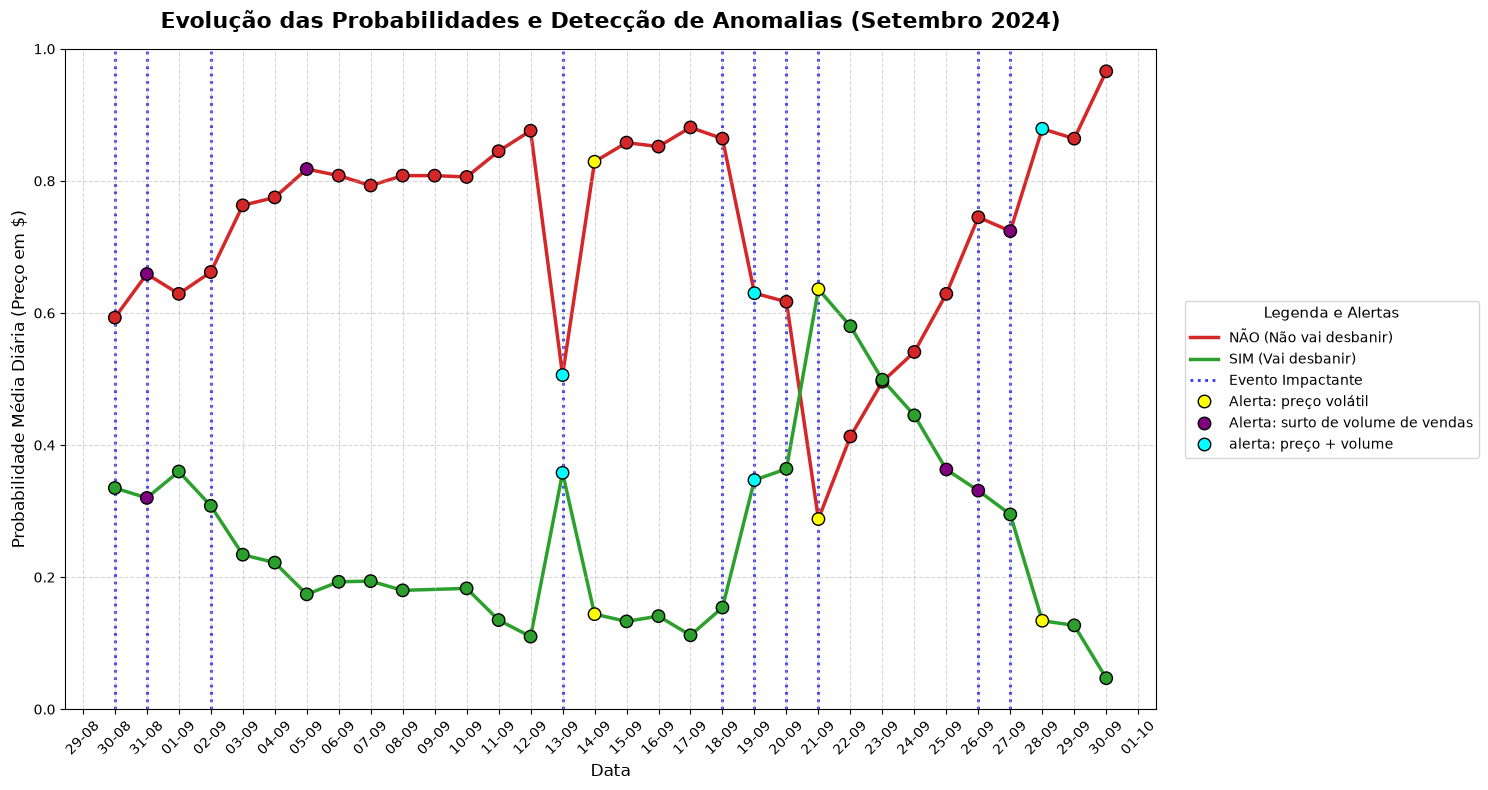

In [30]:
caminho_csv = 'dados/query-final-com-alertas.csv'

#carregando dados
df = pd.read_csv(caminho_csv)
df['trade_date'] = pd.to_datetime(df['trade_date'])

cores = {
    'SIM (Vai desbanir)': '#2ca02c', # Verde
    'NÃO (Não vai desbanir)': '#d62728' # Vermelho
}

#define a cor da bolinha com base nos alertas
def definir_cor_marcador(row):
    teve_alerta_preco = str(row['alerta_preco']).startswith('ALERTA')
    teve_alerta_volume = str(row['alerta_volume']).startswith('ALERTA')
    
    if teve_alerta_preco and teve_alerta_volume:
        return 'cyan'    # ciano para ambos os alertas
    elif teve_alerta_preco:
        return 'yellow'  # amarelo apenas para preço
    elif teve_alerta_volume:
        return 'purple'  # roxo apenas para volume
    else:
        # se nao houver alerta, retorna a cor base da própria linha
        tipo = row['tipo_token']
        return cores.get(tipo, 'black')

# aplica a função para criar a coluna de cores
df['cor_marcador'] = df.apply(definir_cor_marcador, axis=1)
# ------------------------------------------------------------------------

#configurando a visualização do gráfico
plt.figure(figsize=(15, 8))

#itera sob cada aposta
for tipo, grupo in df.groupby('tipo_token'):
    # desenha a linha
    plt.plot(
        grupo['trade_date'], 
        grupo['prob_atual'], 
        label=tipo, 
        color=cores.get(tipo, 'blue'), 
        linewidth=2.5,
        zorder=1 
    )
    
    # desenha as bolinhas
    plt.scatter(
        grupo['trade_date'], 
        grupo['prob_atual'], 
        c=grupo['cor_marcador'], 
        s=80, 
        edgecolors='black',
        linewidth=1,
        zorder=2
    )

# titulos e labels
plt.title('Evolução das Probabilidades e Detecção de Anomalias (Setembro 2024)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Probabilidade Média Diária (Preço em $)', fontsize=12)
plt.ylim(0, 1)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m')) 
plt.xticks(rotation=45)

datas_eventos = [
    '2024-08-30', '2024-08-31', '2024-09-02', '2024-09-13', 
    '2024-09-18', '2024-09-19', '2024-09-20', '2024-09-21', 
    '2024-09-26', '2024-09-27'
]

# adiciona as linhas verticais pontilhadas
legenda_inserida = False
for data_str in datas_eventos:
    data_dt = pd.to_datetime(data_str)
    if not legenda_inserida:
        plt.axvline(x=data_dt, color='blue', linestyle=':', linewidth=2, alpha=0.8, label='Evento Impactante', zorder=0)
        legenda_inserida = True
    else:
        plt.axvline(x=data_dt, color='blue', linestyle=':', linewidth=2, alpha=0.8, zorder=0)

plt.grid(True, linestyle='--', alpha=0.5)

# monta a legenda
handles, labels = ax.get_legend_handles_labels()

# adiciona manualmente as marcações das bolinhas para explicar as cores de alerta
bolinha_amarela = mlines.Line2D([], [], color='yellow', markeredgecolor='black', marker='o', linestyle='None', markersize=9, label='Alerta: preço volátil')
bolinha_roxa = mlines.Line2D([], [], color='purple', markeredgecolor='black', marker='o', linestyle='None', markersize=9, label='Alerta: surto de volume de vendas')
bolinha_ciano = mlines.Line2D([], [], color='cyan', markeredgecolor='black', marker='o', linestyle='None', markersize=9, label='alerta: preço + volume')

handles.extend([bolinha_amarela, bolinha_roxa, bolinha_ciano])

# Move a legenda ligeiramente para fora do gráfico para não cobrir os dados
plt.legend(handles=handles, title='Legenda e Alertas', fontsize=10, title_fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5))
# --------------------------------------

plt.tight_layout()
plt.show()

Abaixo, iremos analisar os casos em que os alertas estão coincindindo com os eventos jurídicos mapeados:

- Dia 31/8: O bloqueio do Twitter é efetivado por todas as operações de internet. O otimismo com relação ao desbanimento aumenta
- Dia 13/9: Moraes determina a transferência de R$ 18,3 milhões que foram bloqueados nas contas da Starlink e da rede social X para a União. Foram ativados ambos os alertas. No dia, a opinião do público se mostrou mais otimista, mas logo decaiu novamente.
- Dia 19/9: Nesse dia, X informa ao STF que pretende reativar representação legal no Brasil, e Moraes dá 24 horas para a empresa comprovar a medida e entregar documentos. A opinião do público passa a ser mais otimista. 
- Dia 21/9: A aposta de que o X seria desbanido superou a do não banimento pela primeira vez. Entretanto, Moraes pede novos documentos. Para o ministro, a entrega não foi devidamente cumprida. A partir daí, a aposta de que não haverá o desbanimento passa a encarecer.
- Dia 26/9: Surto de apostas. Os advogados do X apresentam os documentos solicitados. A tendência de preços não muda.
- Dia 27/9: O ministro nega o desbloqueio e faz novas determinações. No dia seguinte, o consenso passa a ser de que não haverá desbanimento. Conforme o fim do mês se aproxima, as apostas para o não desbanimento se aproximam do valor máximo (1).

## Conclusões

Podemos observar que algumas apostas aparentam estar correlacionadas com os eventos jurídicos mapeados. Entretanto, não é possível indicar o grau da correlação, já que existem muitas variáveis desconhecidas nesse tipo de evento político.

Para evolução desse trabalho, seria interessante agrupar as apostas em intervalos de tempo menores, como, por exemplo, de 12 em 12 horas ou de 6 em 6 horas. Isso aumentaria o número de amostras e tornaria as variações do gráfico mais compreendidas. Um mapeamento de mais eventos impactantes de naturezas distintas com data e **hora** também poderiam ser mais úteis para compreender melhor as variações.
